In [6]:
import os
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.analyses.cat_spc import plot_cat_spc
import matplotlib.pyplot as plt

In [2]:
data_name = "TalmiEEG"
data_query = "data['subject'] > 0"
category_field = "condition"
ylim = [0, .8]

In [3]:
import jax.numpy as jnp
from jaxcmr.typing import Array, Integer, RecallDataset


def expand_categories_by_recall(
    dataset: RecallDataset,
    category_field: str,
) -> Integer[Array, " trial_count study_positions"]:
    """Returns category labels split by recall outcome.

    Args:
      dataset: Recall dataset providing study event metadata.
      category_field: Key in ``dataset`` with per-item category labels.
    """
    categories = dataset[category_field]
    presentations = dataset["pres_itemnos"]
    recalls = dataset["recalls"]

    recall_hits = jnp.any(
        (recalls[:, :, None] == presentations[:, None, :]) & (recalls[:, :, None] > 0),
        axis=1,
    )
    recall_flags = recall_hits.astype(categories.dtype)
    remapped = categories * 2 - 1 + recall_flags
    return jnp.array(jnp.where(categories > 0, remapped, 0), dtype=jnp.int32)


In [ ]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)

data['condition_by_recall'] = expand_categories_by_recall(data, category_field)
data['condition_by_recall']

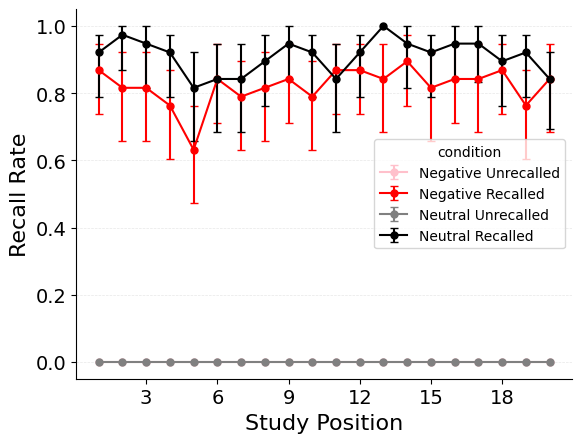

In [11]:
axis = plot_cat_spc(
    datasets=[data],
    trial_masks=trial_mask,
    category_field='condition_by_recall',
    category_values=[1, 2, 3, 4],
    contrast_name="condition",
    labels=["Negative Unrecalled", "Negative Recalled", "Neutral Unrecalled", "Neutral Recalled"],
    color_cycle=["pink", "red", "gray", "black"],
)
# axis.set_ylim(tuple(ylim))
# plt.savefig(output_path, bbox_inches="tight", dpi=600)